In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data = pd.read_csv(Path.cwd().parents[1] / "ml" / "data" / "fuel_consumption.csv")

In [6]:
X = data["distance_km"].to_numpy()
y = data["fuel_consumption"].to_numpy()

print(X.shape)
print(y.shape)

(500,)
(500,)


In [7]:
def predict(X, w, b):
    return X * w + b

In [8]:
def compute_cost(X, y, w, b):
    m = len(X)
    predictions = predict(X, w, b)
    errors = predictions - y
    cost = np.sum(errors ** 2) / (2 * m)
    return cost

In [9]:
def compute_gradient(X, y, w, b):
    m = len(X)
    predictions = predict(X, w, b)
    errors = predictions - y
    dj_dw = np.sum(errors * X) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

In [4]:
def gradient_descent(X, y, w, b, alpha, num_iters):
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
    return w, b, cost_history

In [10]:
w,b,cost_history = gradient_descent(X, y, w=0, b=0, alpha=0.000001, num_iters=5000)

print("w: ", w)
print("b: ", b)
print("Final cost: ", cost_history[-1])
print("Initial cost: ", cost_history[0])

w:  0.07978546486637214
b:  0.00013669426913593012
Final cost:  1.158804021408402
Initial cost:  420.6041470141895


In [11]:
distance = 250

estimated_fuel_consumption = predict(distance, w, b)

print(f"Estimated fuel consumption for {distance} km: {estimated_fuel_consumption:.2f} liters")

Estimated fuel consumption for 250 km: 19.95 liters


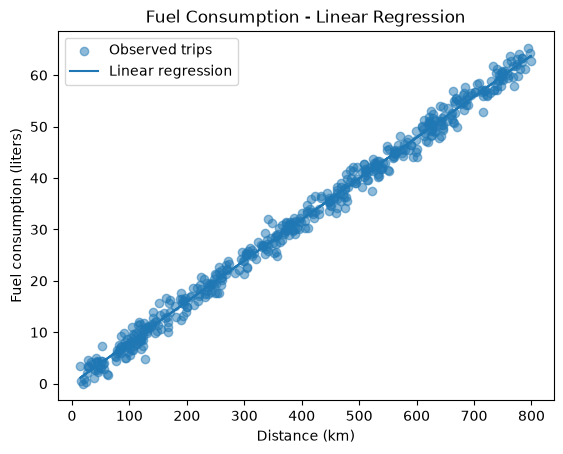

In [12]:
predictions = predict(X, w, b)

plt.scatter(
    X,
    y,
    alpha=0.5,
    label="Observed trips"
)

plt.plot(
    X,
    predictions,
    label="Linear regression"
)

plt.xlabel("Distance (km)")
plt.ylabel("Fuel consumption (liters)")
plt.title("Fuel Consumption - Linear Regression")
plt.legend()

plt.show()

In [13]:
rng=np.random.default_rng(42)
indices= rng.permutation(len(X))
split_index = int(len(X) * 0.8)
train_indices = indices[:split_index]
test_indices = indices[split_index:]
x_train, y_train = X[train_indices], y[train_indices]
x_test, y_test = X[test_indices], y[test_indices]

In [15]:
initial_w = 0
initial_b = 0
learning_rate = 0.000001
iters = 5000
w,b, cost_history = gradient_descent(x_train, y_train, initial_w, initial_b, learning_rate, iters)

test_predictions = predict(x_test, w, b)
test_mae=np.mean(np.abs(test_predictions - y_test))

train_predictions = predict(x_train, w, b)
train_mae = np.mean(np.abs(train_predictions - y_train))

print(f"Train MAE: {train_mae:.2f} liters")
print(f"Test MAE: {test_mae:.2f} liters")



Train MAE: 1.22 liters
Test MAE: 1.13 liters
